# <center> ISEL - PIV </center>
## <center>Semestre 2024/25 </center>
###  <center> Trabalho 1 - Contagem e Classificação de Peças de LEGO Retangulares</center>

Trabalho realizado por:
* Miguel Alcobia, número <b> 50746 </b>
* Tomás Salvador, número <b> 50766 </b>

<b> Grupo 8 </b> <br></br>
<b> Turma 51D </b> <br></br>
<b> Docente: Pedro Mendes Jorge </b>

# Índice

1. [Introdução](#introducao)
2. [Desenvolvimento - Trabalho Prático 1](#desenvolvimento)
    1. [Leitura de imagens](#leituraImg)
    2. [Binarização](#binarizacao)
    3. [Melhoramento  da imagem](#melhorImg)
    4. [Extração de componentes conexos e Extração de propriedades](#extração)
    5. [Classficação de objetos](#classificacao)
3. [Conclusão](#conclusao)

# Introdução <a name="introducao"></a>

<div style="text-align: justify">

Este trabalho tem como objetivo principal o desenvolvimento de um algoritmo de visão por computador capaz de identificar, contar e classificar peças de LEGO de dimensões conhecidas, num ambiente controlado. O trabalho deverá conseguir lidar e ultrapassar possíveis perturbações, como a presença de outras peças de LEGO, incluindo peças que devem ser descartadas, sombras e contacto entre as peças. O cenário será constituído por uma mesa com superfície homogénea e clara, observada por uma câmara montada num tripé, onde as peças de LEGO vão estar distribuidas.

Este trabalho vai permitir melhorar o conhecimento teórico e sobretudo prático sobre as técnicas de processamento de imagem, como a binarização, a morfologia, a deteção de contornos, e a extração de propriedades de objetos que foram os principais temas abordados ao longo das primeiras aulas.

</div>

# Desenvolvimento - Trabalho Prático 1 <a name="desenvolvimento"></a>

## Imports <a name="imports"></a>

In [281]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## 1. Leitura de imagens <a name="leituraImg"></a>

In [282]:
folder_name = "treino/" # Alterar pasta das imagens aqui
filename = "lego01.jpg" # Alterar imagens aqui

img = cv.imread(folder_name+filename)

## 2. Binarização <a name="binarizacao"></a>

<div style="text-align: justify">

A binarização de imagens é uma técnica muito comum no processamento de imagens e visão por computador, sendo amplamente utilizada para converter uma imagem numa imagem binária, onde os pixeis são representados por dois valores: 0 (preto) e 1 (branco), ou, em termos de intensidade, 0 e 255. Este processo simplifica a análise de imagens, uma vez que permite destacar as áreas de interesse, facilitando assim a deteção de objetos, contornos e regiões de destaque.

Muitas vezes as imagens possuem variações de iluminação ou sombras, o que pode dificultar o processo de binarização. Para superar essas limitações podemos recorrer a um valor que funcionará como limiar (threshold) que pode ser ajustado para separar regiôes da imagem com base no valor dos seus pixeis.

Quando defenimos um threshold, cada pixel da imagem é comparado a esse valor: se o valor de intensidade do pixel for maior que o limiar, atribui-se o valor máximo (1), caso contrário, atribui-se o valor mínimo (0).

Nesta primeira fase do trabalho começou-se por analisar as imagens e ver a distribuição dos niveis de cor. Para isso observaram-se os histogramas de cada cor individualmente.

</div>

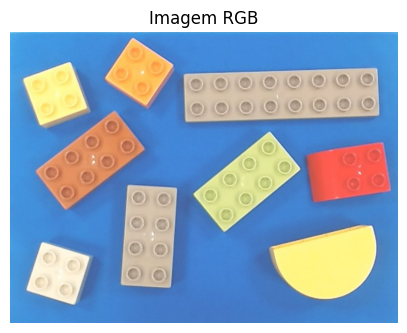

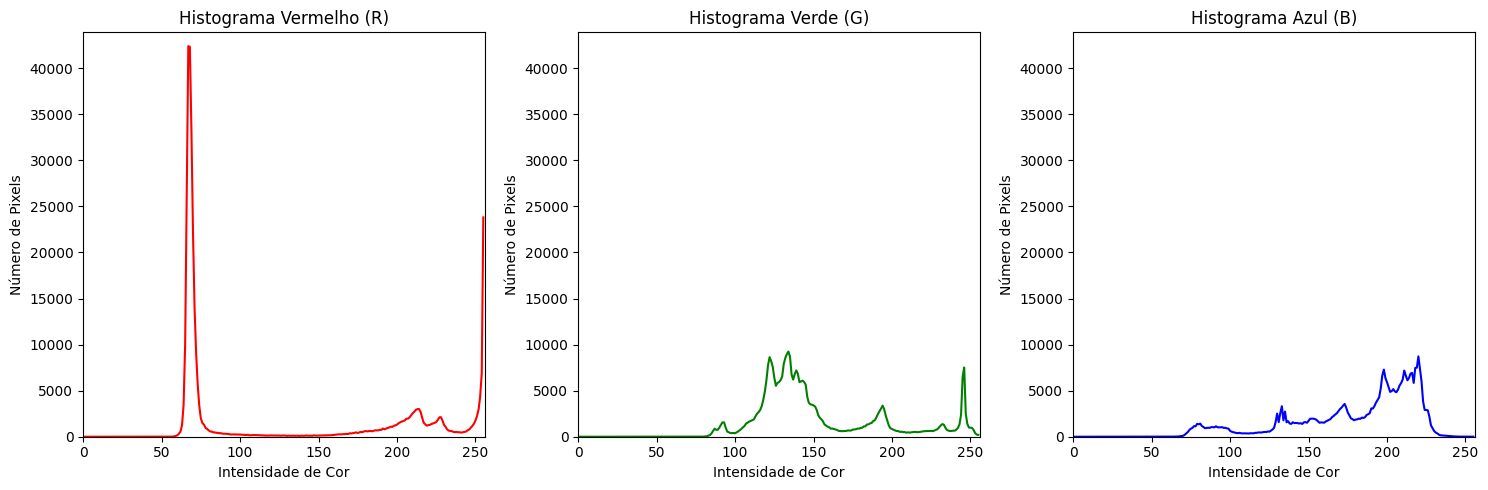

In [283]:
# Conversão para rgb
imagem_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Plot da imagem
plt.figure(figsize=(5,5))
plt.imshow(imagem_rgb)
plt.title('Imagem RGB')
plt.axis('off')


# Separar os canais
r, g, b = cv.split(imagem_rgb)

# Calcular os histogramas
hist_r = cv.calcHist([r], [0], None, [256], [0, 256])
hist_g = cv.calcHist([g], [0], None, [256], [0, 256])
hist_b = cv.calcHist([b], [0], None, [256], [0, 256])

# O valor máximo entre os histogramas para igualar o eixo y
y_max = max(hist_r.max(), hist_g.max(), hist_b.max()) + 1500

# Plot dos histogramas
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(hist_r, color='red')
plt.title('Histograma Vermelho (R)')
plt.xlim([0, 256])
plt.ylim([0, y_max])
plt.xlabel('Intensidade de Cor')
plt.ylabel('Número de Pixels')

plt.subplot(1, 3, 2)
plt.plot(hist_g, color='green')
plt.title('Histograma Verde (G)')
plt.xlim([0, 256])
plt.ylim([0, y_max])
plt.xlabel('Intensidade de Cor')
plt.ylabel('Número de Pixels')

plt.subplot(1, 3, 3)
plt.plot(hist_b, color='blue')
plt.title('Histograma Azul (B)')
plt.xlabel("Valor dos pixeis")
plt.xlim([0, 256])
plt.ylim([0, y_max])
plt.xlabel('Intensidade de Cor')
plt.ylabel('Número de Pixels')
plt.tight_layout()
plt.show()

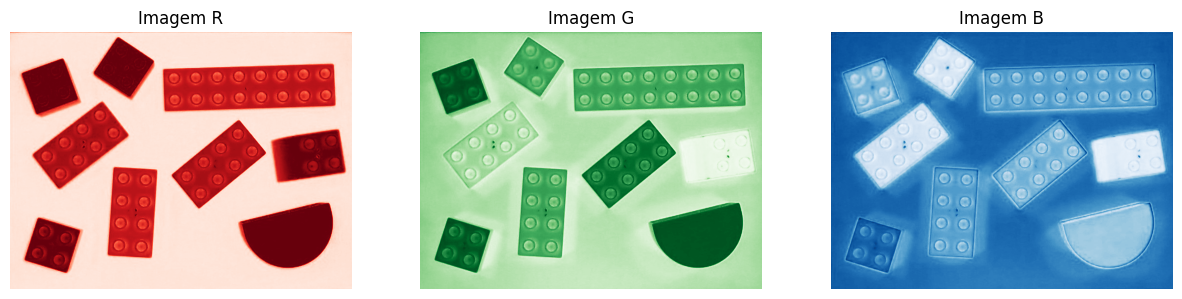

In [284]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Exibir o canal R
ax[0].imshow(r, cmap='Reds')
ax[0].set_title('Imagem R')
ax[0].axis('off')

# Exibir o canal G
ax[1].imshow(g, cmap='Greens')
ax[1].set_title('Imagem G')
ax[1].axis('off')

# Exibir o canal B
ax[2].imshow(b, cmap='Blues')
ax[2].set_title('Imagem B')
ax[2].axis('off')

plt.show()

<div style="text-align: justify">
Ao observar os histogramas e as imagens que deles resultam, é notável que o fundo azul fica mais destacado comparando ao resto da imagem na imagem do canal vermelho. No respetivo histograma, é possível ver um pico no número de pixeis que têm uma intensidade baixa de vermelho, o que indica a zona onde provavelmente os pixeis do fundo se encontram.
<br><br>
Após a observação acima optou-se por fazer o threshold sobre o canal vermelho.
</div>

<div style="text-align: justify">

Para iniciar a binarização com o objetivo de separar as peças de lego do fundo azul das imagens recorremos á função ``threshold`` do Open CV. Esta função permite aplicar uma binarização num canal específico da imagem (no nosso caso, o canal vermelho)

* ``r`` - Seleciona o canal ao qual vai ser aplicada a binarização

* ``117`` - Corresponde ao valor do limiar, desta forma todos os pixeis da imagem que tiverem um valor de intensidade maior ou igual a este limiar (117) serão definidos como o valor máximo (255), enquanto os pixeis com valor menor que o limiar serão definidos como 0 (preto). 

* ``255`` - Valor máximo que será atribuído aos pixeis que atendem ao critério da binarização, ou seja aqueles cuja intensidade for maior ou igual a 117. 

* ``THRESH_BINARY`` - Tipo de binarização aplicada,  neste tipo os pixeis acima do limiar recebem o valor máximo (255), e os abaixo do limiar recebem o valor mínimo (0).

O facto do valor escolhido ter sido o 117, foi o facto de ter sido o valor com melhor resultado para as imagens de teste, após outros testes com outros valores. Como é possível ver no histograma, o pico que corresponde ao fundo acaba por volta da intensidade 100, logo 117 é um valor que parece lógico e aceitável.
    
Não se escolheu o ``THRESH_OTSU``, pois optou-se pela autonomia na escolha do valor do limiar e o Otsu calcula automaticamente um valor de limiar e trabalha com ele. 

Após esta fase, tornou-se possível separar as peças de LEGO do fundo, embora essa separação ainda não seja muito precisa, surgindo a necessidade de melhorar essa separação na fase seguinte.
</div>

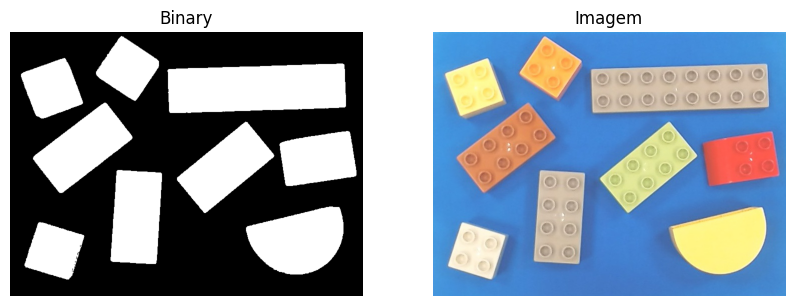

In [285]:
# Aplicar a binarização ao canal vermelho (r) usando um limiar fixo de 117
ret, thresh = cv.threshold(r, 117, 255, cv.THRESH_BINARY)

# Plots das imagens
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.imshow(thresh, cmap='gray')
plt.title('Binary')
plt.axis('off') 
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)) 
plt.title('Imagem')
plt.axis('off')
plt.show()

## 3. Melhoramento da imagem <a name="melhorImg"></a>

<div style="text-align: justify">
Nesta fase, para melhorar a separação das peças de LEGO, recorreu-se à aplicação de operações morfológicas, nomeadamente a erosão e a dilatação. A erosão é fundamental para remover pequenos ruídos e imperfeições que interferem na deteção dos contornos das peças. Ao aplicar a erosão com um elemento estrutural retangular, conseguimos reduzir o tamanho de objetos menores e eliminar áreas de sobreposição entre peças adjacentes, ajudando a separar peças que se encontravam encostadas. Em seguida, aplicou-se a dilatação, que expande as áreas de interesse na imagem, permitindo restaurar o tamanho das peças e definir melhor os seus contornos após a erosão. Estas operações resultaram numa máscara mais limpa e com uma melhor definição dos contornos, facilitando a identificação e a contagem das peças após a aplicação da máscara.
</div>

<div style="text-align: justify">

Para encontrar os contorno recorreu-se ao método ``findContours()``.
Esta função recebe como parâmetros a imagem sobre a qual vai delinear os contornos, o método que recupera os contornos, neste caso o ``RETR_TREE`` que recupera todos os contornos e cria uma hierarquia entre eles, e o método ``CHAIN_APPROX_SIMPLE`` que elimina  pontos redundantes e comprime o contorno, economizando memória.

Para desenhar os contornos recorreu-se ao método ``drawContours()``, com os seguintes parâmetros:``drawContours(inter_mask, [cnt], 0, 255, -1)``, que vai percorrer todos os contornos encontrados anteriormento, começando pelo ``0``, e preenche a área delimitada pelos contornos devido ao valor ``-1`` (se fosse um valor positivo representaria a espessura do contorno), de forma a remover o ruido interno dos contorno, com a cor branca (``255``).

Em seguida, recorreu-se ao método ``getStructuringElement()`` para criar os elementos estruturais para as operações seguintes, estes elementos terão a forma de um retângulo (``MORPH_RECT``) com a dimensão 7x7 e outro com 3x3. O facto de ter-se escolhido um retângulo deve-se ao formato das peças de LEGO que devem ser selecionadas. A razão do tamanho ser 7x7 e 3x3 resulta do facto de após alguns testes com outros tamanhos ((4,4), (5,5), (8,8), (11,11)) verificou-se que estes tamanhos originavam o melhor resultado para a abordagem tomada pelo grupo.

Cada elemento será aplicado numa operação diferente, utilizou-se primeiro a erosão para remover o ruído de forma a separar as peças que se encontram juntas. Escolheu-se uma dimensão 7x7, porque já tem uma dimensão considerável e cumpre o objetivo sem danificar muito a imagem. Em seguida aplicou-se a dilatação com um tamanho menor (3x3), para se conseguir recuperar alguma da informação perdida sem desfazer as separações das peças que resultaram da erosão.

Para aplicar-se a operação  **erosão** com o objetivo de reduzir o ruido e tentar separar as peças de LEGO que se encontravam encostadas, recorreu-se à função ``erode()`` . Esta recebe a imagem sobre a qual vai efetuar a operação, recebe o kernel criado anteriormente com o ``getStructuringElement()`` e recebe número de iterações de erosão a serem aplicadas. Um número maior de iterações aumenta o efeito da erosão, resultando na remoção de mais detalhes e, consequentemente, pode provocar a perda de informação importante na imagem.
    

Para recuperar parte do que foi perdido, recorreu-se à operação de **dilatação** através da função ``dilate()``. Esta função tem um efeito oposto ao da erosão: em vez de reduzir o tamanho dos elementos, expande-os, preenchendo pequenas lacunas e restaurando detalhes que possam ter sido eliminados em excesso durante a erosão. A dilatação permite, assim, reconstruir ligeiramente as bordas e recuperar partes das peças que possam ter sido desgastadas, contribuindo para uma definição mais precisa dos contornos das peças de LEGO e garantindo uma separação mais adequada na imagem final.

Após vários testes com diversos valores chegou-se à conclusão que 2 duas iterações seria o valor que exibia os melhores resultados para ambas as operações.
</div>

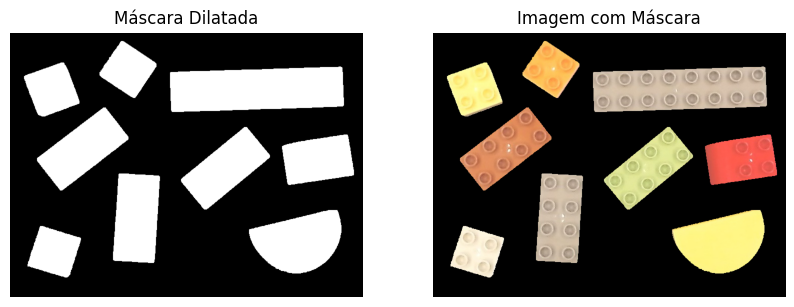

In [286]:
# Mascara intermedia para preencher buracos do threshold
inter_mask = thresh.copy()

# Encontra os contornos na imagem binária
contour, hier = cv.findContours(inter_mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Para cada contorno encontrado, desenha-o na máscara
for cnt in contour:
    # Preenche os contornos desenhados com a cor branca 
    cv.drawContours(inter_mask, [cnt], 0, 255, -1)  
    
# Guardar a imagem com os contornos desenhados
mask = inter_mask

# Kernel para as operações morfológicas
kernel_erode = cv.getStructuringElement(cv.MORPH_RECT, (7,7))
kernel_dilate = cv.getStructuringElement(cv.MORPH_RECT, (3,3))

# Aplica a erosão à máscara para remover o ruído
mask_erode = cv.erode(mask, kernel_erode, iterations=2)

# Aplica a dilatação à máscara para recuperar informação
mask_dilate = cv.dilate(mask_erode, kernel_dilate, iterations=2)

# Converte a máscara dilatada binaria para uma imagem BGR para aplicar à imagem original
mask = cv.cvtColor(mask_dilate, cv.COLOR_GRAY2BGR)

# Aplica a máscara à imagem original
result = cv.bitwise_and(img, mask)

# Visualização dos resultados
plt.figure(figsize=(10, 5))

# Mostrar a mascara dilatada
plt.subplot(1, 2, 1)
plt.imshow(mask, cmap='gray')
plt.title('Máscara Dilatada')  
plt.axis('off')  

# Exibe a imagem original com a máscara aplicada
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))  
plt.title('Imagem com Máscara')  
plt.axis('off')  

plt.show()

<div style="text-align: justify">
No final desta fase já conseguimos ver as peças nitidamente separadas do fundo azul, posto isto podemos passar á proxima fase.
</div>

## 4. Extração de componentes conexos e Extração de propriedades <a name="extração"></a>

<div style="text-align: justify">
    
A extração de componentes conexos é o processo de identificar e marcar os grupos de pixeis que estão interligados numa imagem, formando uma estrutura contínua. Este método é frequentemente utilizado para separar os objetos numa imagem. Esta separação é crucial para tarefas como contagem de objetos, como é o caso das peças de LEGO no contexto do trabalho.

Por outro lado, a extração de propriedades consiste na análise das características geométricas e físicas dos componentes identificados. Após a separação dos objetos, propriedades como a área, o perímetro, a forma, a orientação, e outros atributos dos objetos detectados podem ser calculadas. Essas informações são úteis para a fase de classificação e identificação de objetos. Por exemplo, no contexto das peças de LEGO, a análise das propriedades dos componentes vai ajudar a identificar os diferentes tamanhos e formatos, facilitando a contagem e a classificação das peças.

Nesta fase, o objetivo foi identificar e contar as peças retangulares de Lego na imagem. Primeiro, aplicámos a técnica de deteção de contornos após a aplicação da erosão para melhorar a separação entre as peças. Em seguida, verificámos cada contorno para determinar se ele poderia ser aproximado a um polígono com 4 lados, o que é característico das peças retangulares. As peças que satisfazem esse critério foram contadas e destacadas com contornos verdes. As peças que não atenderam à condição de 4 lados foram descartadas e marcadas com contornos vermelhos. No final, obtivemos a contagem total de peças detectadas e o número de peças retangulares.

Voltou-se a obter os contornos após a erosão e utilizou-se a função ``convexhull()`` para ajudar a simplificar a forma das peças, eliminando as concavidades ou pequenas irregularidades nos contornos.

A função ``arcLength()`` foi utilizada para calcular o perímetro do contorno que vai ser usado para ajustar o valor de aproximação do contorno. O parâmetro ``True`` indica que o contorno é fechado.

A função ``approxPolyDP()`` aproxima o contorno a um polígono e foi utilizada para identificar se uma peça tem uma forma retangular, ou seja, se o contorno aproximado possui 4 lados. Se puder ser aproximado então considerou-se que é uma peça de LEGO retangular e por isso pode ser contabilizada. Para além do contorno esta função também recebe como parâmetro o fator de tolerância para a aproximação. Que quanto maior o valor, mais simplificada será a forma do contorno. No nosso caso, epsilon é definido como 2% do perímetro calculado com ``arcLength()``, porque foi o valor que visualmemte apresentou melhores resultados.

O contorno das peças reconhecidas foram pintadas a verde e as indefinidas a vermelho. 
    
</div>

Número de peças detectadas: 9
Número de peças com 4 lados: 8


(-0.5, 705.5, 529.5, -0.5)

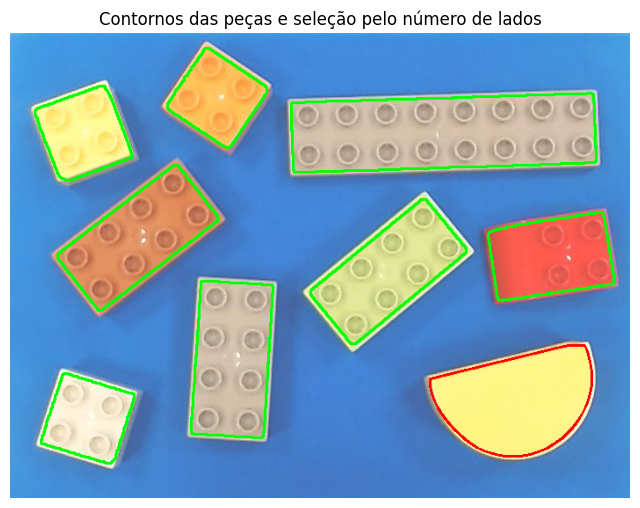

In [287]:
# Contornos após as operações morfológicas
contornos, hierarquia = cv.findContours(mask_dilate, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Contar o número total de contornos neste caso o número de peças detectadas
numero_de_contornos = len(contornos)

# Contador de peças com 4 lados
pecas_retangulares = 0

# Cópia da imagem original para desenhar os contornos
img_contours = img.copy()

contornos_val = []
contornos_descartados = []

for contorno in contornos:
    # Obter o convex hull do contorno
    hull = cv.convexHull(contorno)

    # Aproximar o contorno a um polígono
    epsilon = 0.02 * cv.arcLength(contorno, True)
    approx = cv.approxPolyDP(contorno, epsilon, True)

    # Verificar se o polígono tem 4 lados
    if len(approx) == 4:
        pecas_retangulares += 1
        # Adicionar o contorno aos contornos válidos
        contornos_val.append(contorno)
        # Desenhar o contorno a verde
        cv.drawContours(img_contours, [contorno], -1, (0, 255, 0), 2) 
    else:
        # Adicionar o contorno à lista de contornos descartados
        contornos_descartados.append(contorno)
        # Desenhar o contorno descartado a vermelho
        cv.drawContours(img_contours, [hull], -1, (0, 0, 255), 2) 
        
# Exibir o número de peças detectadas e o número de peças com 4 lados
print(f"Número de peças detectadas: {numero_de_contornos}")
print(f"Número de peças com 4 lados: {pecas_retangulares}")


# Plot da Imagem
image_c = img_contours.copy()
image_c = cv.cvtColor(image_c, cv.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(image_c)
plt.title('Contornos das peças e seleção pelo número de lados')
plt.axis('off')

<div style="text-align: justify">
No fim desta fase, já é possível excluir todas as peças que não são retangulares e que por isso não deviam ser contabilizadas. Contudo, ainda faltam excluir as peças que são retangulares, mas não se encontram no grupo que deve ser classificado.
</div>

<div style="text-align: justify">

Com as peças retangulares separadas, era importante conseguir separar as peças que deveriam ser classificadas com as dimensões pretendidas daquelas que possuiam outras dimensões. Para isso utilizou-se o **aspect ratio**.

O aspect ratio é definido como a razão entre a largura e a altura de um objeto retangular, e pode ser calculado a partir do **bounding box** (a menor caixa retangular que envolve completamente um objeto).

Através do aspect ratio, podem distinguir-se os diferentes tipos de peças. Como sabemos as peças que queremos classificar, sabemos que têm uma forma retangular com proporções conhecidas, podemos calcular o aspect ratio de cada contorno detectado e comparar com os valores esperados. As peças que tenham um aspect ratio dentro de uma determinada faixa de valores podem ser consideradas como válidas, enquanto as peças que se desviam muito dessa faixa podem ser descartadas.

Considerou-se que esta seria uma boa forma de classificar as peças, pois independente do tamanho exato da peça, focou-se apenas na sua proporção. Assim, mesmo que as peças apareçam em diferentes escalas ou posições na imagem, o aspect ratio permanece consistente, facilitando a deteção das peças desejadas.

</div>

<div style="text-align: justify">

Para garantir que o aspect ratio fosse calculado de forma correta recorreu-se ao método ``minAreaRect()`` que encontra o menor retângulo que circunscreve cada peça, sendo assim uma medida confiável da forma da peça. Este método retorna as coordenadas do centro do retângulo, a largura e altura (dimensões), e o ângulo de rotação do retângulo.

Através do método ``boxPoints()`` calculou-se as coordenadas dos quatro vértices do retângulo rotacionado definido anteriormente. Isto permite desenhar o contorno exato de cada peça como um retângulo rotacionado, independentemente da sua orientação, garantindo uma representação mais precisa das bordas das peças LEGO.

Para desenhar os contornos voltou-se a usar o ``drawContours()``.

</div>

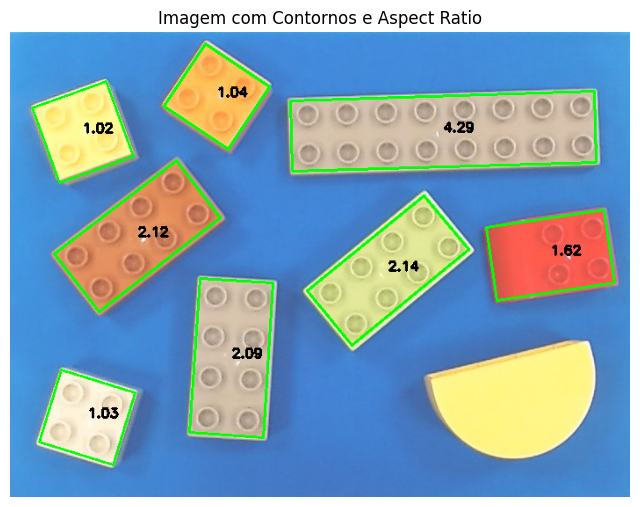

In [288]:
img_aratio = img.copy()

# Percorrer cada contorno detetado
for contorno in contornos_val:
    # Calcular o centroide do contorno para posicionar o texto
    M = cv.moments(contorno)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])  # Coordenada X 
        cY = int(M["m01"] / M["m00"])  # Coordenada Y 
    else:
        # Caso o momento seja zero, define o centroide como (0, 0)
        cX, cY = 0, 0  

    # Obter o retângulo rotacionado com a menor área que circunscreve o contorno
    rot_rect = cv.minAreaRect(contorno)
    # cx, cy = centro, w = largura, h = altura, angle = ângulo de rotação
    (cx, cy), (w, h), angle = rot_rect  
    if h > w:
        # Inverter os valores se a altura for maior que a largura
        w, h = h, w  

    # Calcular a razão do aspect ratio
    aspect_ratio = float(w) / h
   
    # Obter os 4 vértices do retângulo rotacionado
    box = cv.boxPoints(rot_rect)  
    
    # Converter as coordenadas dos vértices para inteiros
    box = np.intp(box)  
    
    # Desenhar o contorno do retângulo rotacionado a verde
    cv.drawContours(img_aratio, [box], 0, (0, 255, 0), 2)  

    # Escrever a razão na imagem no centro das peças
    cv.putText(img_aratio, f"{aspect_ratio:.2f}", (int(cx), int(cy)), cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

# Converter a imagem de BGR para RGB 
img_areas_rgb = cv.cvtColor(img_aratio, cv.COLOR_BGR2RGB)

# Exibir a imagem
plt.figure(figsize=(8, 8))
plt.imshow(img_areas_rgb)
plt.title('Imagem com Contornos e Aspect Ratio')
plt.axis('off') 
plt.show()

## 5. Classificação de objetos <a name="classificacao"></a>

<div style="text-align: justify">

Após a extração dos contornos relevantes, já é possível identificar e isolar as peças desejadas com base nas suas propriedades geométricas. Com as peças de LEGO desejadas devidamente separadas, procedeu-se então à etapa da classificação de objetos, onde, através da análise do aspect ratio, conseguimos distinguir e classificar cada peça conforme as dimensões predefinidas, como "2x2", "2x4", "2x6" e "2x8". Esta classificação permite-nos diferenciar as peças de interesse de outros objetos ou peças com formatos diferentes na imagem, tornando o processo de identificação e contagem mais funcional.

Além do aspect ratio, o número de lados que o contorno possui também foi usado como parâmetro de classficação no ponto **4 - Extracção de componentes conexos e Extracção de propriedades**. Logo no final o classificação é feita com base numa árvore de decisão, onde primeiro analisamos as peças quanto ao número de lados e depois quanto às suas proporções.

A análise do aspect ratio de cada contorno detetado, permitiu a classificação das peças com base nas suas proporções. 

Inicialmente, os intervalos de aspect ratio foram determinados para cada dimensão das peças ("2x2", "2x4", "2x6" e "2x8") a partir da análise de algumas fotos do conjunto de teste, de forma a estabelecer limites nos intervalos que representam cada tipo de peça. Em seguida, a peça é classificada, através das proporções, conforme o intervalo que melhor se adequa ao seu aspect ratio, garantindo uma classificação eficiente entre os tamanhos das peças, separando os objetos que não correspondem a nenhuma das dimensões defenidas dentro dos intervalos.

</div>

In [289]:
# Intervalos baseados no aspect ratio para classificar as peças
intervalos_aspect_ratio = {
    '2x8': (3.8, 4.4),  
    '2x6': (2.8, 3.3),  
    '2x4': (1.8, 2.3),  
    '2x2': (0.8, 1.3),  
}

# Listas para armazenar os valores e as classificações das peças
lista_ratios = []
classificacoes = []
contornos_filtrados = []

# Percorrer cada contorno detetado
for contorno in contornos_val:
    # Obter o retângulo rotacionado com menor área que circunscreve o contorno
    rot_rect = cv.minAreaRect(contorno)
     # cx, cy = centro do retângulo, angle = ângulo de rotação
    (cx, cy), (w, h), angle = rot_rect 

    # Garantimos que a largura seja sempre maior que a altura 
    if h > w:
        # Inverter os valores se a altura for maior que a largura
        w, h = h, w 

    # Calcular o aspect ratio
    aspect_ratio = float(w) / h
    lista_ratios.append(aspect_ratio) 
    
    # Classificar a peça 
    classificado = False
    for peca, (min_ratio, max_ratio) in intervalos_aspect_ratio.items():
        if min_ratio <= aspect_ratio <= max_ratio:
            # Classificar as peças
            classificacoes.append(peca) 
            contornos_filtrados.append(contorno)
            classificado = True
            break
    if not classificado:
        # Adicionar à lista dos descartados
        contornos_descartados.append(contorno)  
        
# Exibir a classificação de cada peça com o respetivo aspect ratio
for i, (ratio, peca) in enumerate(zip(lista_ratios, classificacoes), 1):
    print(f"Razão de Aspecto do contorno {i}: {ratio:.2f} - Classificação: {peca}")

Razão de Aspecto do contorno 1: 1.03 - Classificação: 2x2
Razão de Aspecto do contorno 2: 2.09 - Classificação: 2x4
Razão de Aspecto do contorno 3: 1.62 - Classificação: 2x4
Razão de Aspecto do contorno 4: 2.14 - Classificação: 2x4
Razão de Aspecto do contorno 5: 2.12 - Classificação: 2x8
Razão de Aspecto do contorno 6: 4.29 - Classificação: 2x2
Razão de Aspecto do contorno 7: 1.02 - Classificação: 2x2


<div style="text-align: justify">

Por fim, desenhou-se a classificação de cada peça diretamente sobre a imagem no centro de cada peça. Calculou-se o centroide de cada contorno usando os momentos, para garantir que o texto fosse colocado no centro da peça.

Para os contornos que não se enquadraram nos intervalos de proporções predefinidos, classificaram-se as peças como **"Outra"**. Quer as peças que tinham sido excluídas anteriormente por não possuírem apenas 4 lados, quer as peças que foram excluídas devido ao seu aspect ratio não pertencer a nenhum dos intervalos predefenidos foram adicionadas a um array de **"contornos descartados"**, o que facilitou a sua representação na imagem final.

</div>

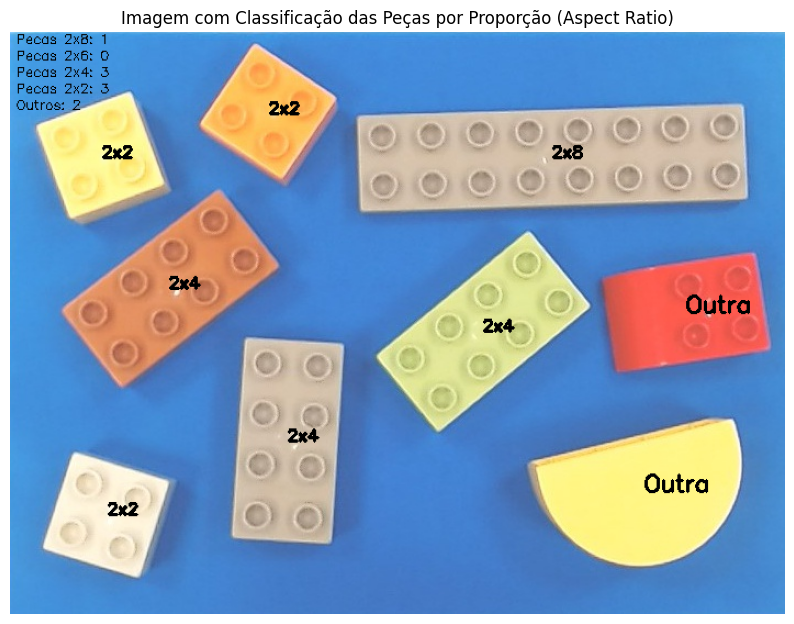

In [290]:
img_classificada = img.copy()

# Plot da Legenda
# Lista completa das classificações possíveis
tipos_de_pecas = ['2x8', '2x6', '2x4', '2x2']

# iniciar o contador para cada tipo de peça
contagem_pecas = {tipo: 0 for tipo in tipos_de_pecas}

# Contar o nº de pecas em cada classificação na lista classificacoes
for classificacao in classificacoes:
    if classificacao in contagem_pecas:
        contagem_pecas[classificacao] += 1

# Escrever a contagem no canto superior esquerdo da imagem
y_pos = 10  # posição inicial
for tipo, count in contagem_pecas.items():
    texto = f"Pecas {tipo}: {count}"
    cv.putText(img_classificada, texto, (5, y_pos), cv.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 1)
    y_pos += 15
    if y_pos == len(tipos_de_pecas)*15 + 10:
         texto = f"Outros: {len(contornos_descartados)}"
         cv.putText(img_classificada, texto, (5, y_pos), cv.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 1)

# Percorrer os contornos classificados para desenhar a classificação de cada peça
for i, contorno in enumerate(contornos_filtrados):
    
    # Calcular o centroide de cada contorno
    M = cv.moments(contorno)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])  # Coordenada X do centroide
        cY = int(M["m01"] / M["m00"])  # Coordenada Y do centroide
    else:
        # Se o momento for zero, define o centroide como 0, 0
        cX, cY = 0, 0  

    # Obter a classificação da peça correspondente
    classificacao = classificacoes[i]
    
    # Desenhar a classificação nas peças da imagem
    cv.putText(img_classificada, classificacao, (cX, cY), cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

# Percorrer os contornos descartados, classificados como "Outra" para desenhar a classificação
for contorno in contornos_descartados:
    
    # Calcular o centroide de cada contorno descartado
    M = cv.moments(contorno)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])  # Coordenada X do centroide
        cY = int(M["m01"] / M["m00"])  # Coordenada Y do centroide
    else:
        cX, cY = 0, 0  

    # Escrever "Outra" nas peças descartadas da imagem
    cv.putText(img_classificada, "Outra", (cX, cY), cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)  

img_classificada_rgb = cv.cvtColor(img_classificada, cv.COLOR_BGR2RGB)

# Exibir a imagem com as classificações desenhadas sobre as peças
plt.figure(figsize=(10, 10))
plt.imshow(img_classificada_rgb)
plt.title('Imagem com Classificação das Peças por Proporção (Aspect Ratio)')
plt.axis('off')  # Ocultar os eixos
plt.show()

# Conclusão <a name="conclusao"></a>

<div style="text-align: justify">

Em suma, o objetivo principal do trabalho foi a identificação e classificação automática de peças de LEGO com diferentes dimensões. Para alcançar este objetivo, o começou-se com a binarização das imagens para distinguir as peças do fundo, seguida pelo melhoramento da imagem para reduzir ruídos indesejados, provocados pelas sombras e pelas bordas da imagem, e destacar as áreas relevantes.

Em seguida, procedeu-se à extração de componentes conexos, onde os contornos das peças foram isolados, e à extração de propriedades geométricas, como o *convex hull* e o *aspect ratio*. Com essas informações, tornou-se possível realizar a classificação das peças, comparando os valores de *aspect ratio* obtidos com os intervalos definidos previamente para as diferentes categorias.

</div>

<div style="text-align: justify">

A última etapa foi a classificação das peças diretamente na imagem, com o desenho das dimensões da classificação sobre as peças de LEGO correspondentes. As peças que não corresponderam a nenhuma das categorias previstas foram classificadas como **"Outras"** e destacadas na imagem, à semelhança das restantes.

Como conclusão, pode afirmar-se que a abordagem baseada no *aspect ratio* demonstrou ser eficaz para classificar as peças com diferentes dimensões, atendendo ao objetivo inicial do trabalho que era identificar e classificar as peças com precisão. A metodologia adotada provou ser eficiente na distinção de peças em função das suas características geométricas.

</div>